# Algorytm Quickhull

Załadowanie potrzebnych struktur i testów

In [8]:
%run interface.ipynb
%run tests.ipynb
import numpy as np

### Algorytm Quickhull - wersja bez wizualizacji algorytmu

In [2]:
def relative_distance(point, segment):
    # oblicza wzgledna odleglosc punktu od prostej
    a, b = segment.first_point, segment.second_point
    return abs((b.x - a.x) * (a.y - point.y) - (a.x - point.x) * (b.y - a.y))

In [3]:
def position(point, segment):
    # okresla polozenie punktu wzgledem zadanej prostej
    a, b = segment.first_point, segment.second_point
    result = (b.x - a.x) * (point.y - a.y) - (b.y - a.y) * (point.x - a.x)
    return (1 if result > 0 else -1 if result < 0 else 0)

In [4]:
def angle(p1, p0):
    delta = [p1.x - p0.x, p1.y - p0.y]
    angle = np.arctan2(delta[1], delta[0])
    return angle

def sort_point(points):
    base_point = min(points, key=lambda p: (p.y, p.x))

    sorted_points = sorted(points, key=lambda p: (angle(p, base_point), p.x, p.y))
    
    return sorted_points


In [5]:
def recursive_algorithm(points, segment):
    
    if not points:
        return []
    
    # znajduje punkt najbardziej oddalony od prostej
    most_distanced_point = max(points, key = lambda point: relative_distance(point, segment))
    points.remove(most_distanced_point)
    
    # tworzy proste i wyznacza zbiory punktow znajdujacych sie nad tymi prostymi
    first_line, second_line = Segment(segment.first_point, most_distanced_point), Segment(most_distanced_point, segment.second_point)
    above_left_line = [point for point in points if position(point, first_line) == 1]
    above_right_line = [point for point in points if position(point, second_line) == 1]
    
    # zwraca punkty nalezace do otoczki wypuklej
    return [most_distanced_point] + recursive_algorithm(above_left_line, Segment(segment.first_point, most_distanced_point)) + recursive_algorithm(above_right_line, Segment(most_distanced_point, segment.second_point))
        

In [6]:
def quickhull(points):
    
    if len(points) <= 2:
        return points
    
    # znajduje punkty skrajne pod wzgledem wspolrzednej x
    left_extreme = min(points, key = lambda point: (point.x, point.y))
    right_extreme = max(points, key = lambda point: (point.x, point.y))
    
    segment = Segment(left_extreme, right_extreme)
    
    # dzieli zbior punktow na te znajdujace sie pod prosta oraz nad prosta
    points_below = [point for point in points if position(point, segment) == -1]
    points_above = [point for point in points if position(point, segment) == 1]
    
    # rekurencyjnie wyznacza punkty nalezace do otoczki
    upper_part = recursive_algorithm(points_above, segment)
    lower_part = recursive_algorithm(points_below, segment.reversed())
    
    result = [left_extreme, right_extreme] + lower_part + upper_part
    return sort_point(result)

### Algorytm Quickhull - testy

Testy poprawnościowe

In [9]:
run_test(quickhull, None)

Test 1:
	Czas: 0.001s
	Wynik: POPRAWNY
Test 2:
	Czas: 0.0034s
	Wynik: POPRAWNY
Test 3:
	Czas: 0.001s
	Wynik: POPRAWNY
Test 4:
	Czas: 0.0s
	Wynik: POPRAWNY
PODSUMOWANIE
Wynik: 4/4
Czas: 0.0054s


Testy czasowe

In [8]:
run_time_tests(quickhull)

Zestaw 1:
Liczba punktów: 100
Czas wykonania algorytmu: 0.0s
Liczba punktów: 500
Czas wykonania algorytmu: 0.001s
Liczba punktów: 1000
Czas wykonania algorytmu: 0.001s
Liczba punktów: 5000
Czas wykonania algorytmu: 0.005s
Liczba punktów: 10000
Czas wykonania algorytmu: 0.0063s
Liczba punktów: 50000
Czas wykonania algorytmu: 0.0715s
Zestaw 2:
Liczba punktów: 100
Czas wykonania algorytmu: 0.0s
Liczba punktów: 500
Czas wykonania algorytmu: 0.001s
Liczba punktów: 1000
Czas wykonania algorytmu: 0.002s
Liczba punktów: 5000
Czas wykonania algorytmu: 0.004s
Liczba punktów: 10000
Czas wykonania algorytmu: 0.0213s
Liczba punktów: 50000
Czas wykonania algorytmu: 0.0954s
Zestaw 3:
Liczba punktów: 100
Czas wykonania algorytmu: 0.0s
Liczba punktów: 500
Czas wykonania algorytmu: 0.0s
Liczba punktów: 1000
Czas wykonania algorytmu: 0.0s
Liczba punktów: 5000
Czas wykonania algorytmu: 0.0s
Liczba punktów: 10000
Czas wykonania algorytmu: 0.0183s
Liczba punktów: 50000
Czas wykonania algorytmu: 0.0647s
Zest

### Zadawanie zbioru punktów

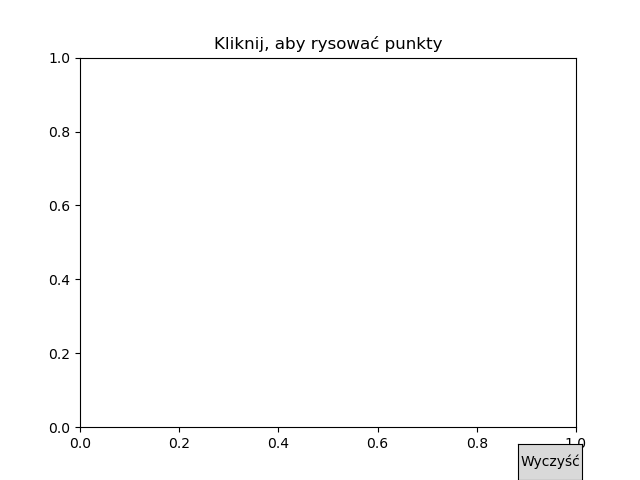

In [7]:
polygon = PolygonDrawer()

### Algorytm Quickhull - wersja z wizualizacją algorytmu

In [8]:
def quickhull_visualisation(points):
    visualizer = ConvexHullVisualizer()
    global hull_points
    segments = []
    hull_points = []
    
    if len(points) <= 2:
        return points
    
    left_extreme = min(points, key = lambda point: (point.x, point.y))
    right_extreme = max(points, key = lambda point: (point.x, point.y))
    
    segment = Segment(left_extreme, right_extreme)
    segments.append(segment)
    
    points_below = [point for point in points if position(point, segment) == -1]
    points_above = [point for point in points if position(point, segment) == 1]
    
    hull_points = [left_extreme, right_extreme]
    upper_part = recursive_algorithm_visualisation(visualizer, points, points_above, segment, segments)
    lower_part = recursive_algorithm_visualisation(visualizer, points, points_below, segment.reversed(), segments)
    
    display(visualizer.create_animation())


def recursive_algorithm_visualisation(visualizer, all_points, points, segment, segments):
    
    global hull_points
    
    if not points:
        return []
    
    most_distanced_point = max(points, key=lambda point: relative_distance(point, segment))
    points.remove(most_distanced_point)
    
    if most_distanced_point not in hull_points:
        hull_points.append(most_distanced_point)
    
    first_line = Segment(segment.first_point, most_distanced_point)
    second_line = Segment(most_distanced_point, segment.second_point)
    
    visualizer.add_frame(all_points, [hull_points], [], segments, None)
    

    above_left_line = [point for point in points if position(point, first_line) == 1]
    above_right_line = [point for point in points if position(point, second_line) == 1]
    
    return (
        [most_distanced_point] + 
        recursive_algorithm_visualisation(visualizer, all_points, above_left_line, first_line, segments) + 
        recursive_algorithm_visualisation(visualizer, all_points, above_right_line, second_line, segments)
    )

Wizualizacja algorytmu Quickhull

In [9]:
quickhull_visualisation(polygon.points)